### Introduction

- [Deltakit stim](https://github.com/Deltakit/deltakit-stim) is a fork of stim which adds the functionality to simulate leakage. It has four additional [operations](https://github.com/Deltakit/deltakit-stim/blob/main/doc/deltakit_stim_gates.md):

    - `LEAKAGE`
        • depolarising leakage. Convert this qubit to the maximally depolarised state if it leaks. Also, any future qubits this qubit interacts with also get fully depolarised.
        • (Future work: could look into the docs to make less harmful leakage model, like Mølmer-Sørensen leakage as per Brown's papers)
        • Reset gates return leaked qubits to the computational subspace

    - `RELAX`
        • Relaxes a leaked qubit back to the maximally depolarised state (which was done with the LEAKAGE instruction) with a given probability. Otherwise does nothing. Once the qubit is relaxed it no longer depolarises qubits it interacts with (it will just transmit errors normally from being a maximally depolarised state)

    - `HERALD_LEAKAGE_EVENT`
        - This is the herald. It heralds / tells you whether a qubit is leaked or not. Consider it a leakage-detecting measurement. It populates the measurement record with this data.
        - Can use this just in front of measurements to simulate a measurement that also detects leakage.
        - Note that Deltakit's leakage model is NOT contagious leakage. A leaked qubit does not cause another to leak, simply to maximally depolarize.
        - So can't be used for loss, which IS contagious in ion traps (walking cat paper explains that trying to merge the coulomb potentials of an ion with another that isn't there results in the loss of the first ion), unless of course you model what the walking cat paper does which is a beacon qubit measurment after every two-qubit gate, then you always know if a qubit is lost. 

    - `RL`
        - Relaxes target qubit into the computational subspace (where it is maximally depolarised). Seems to be equivalent to `RELAX(1)`



<br>

- We work through examples here. Can also see some circuit examples at:
  - https://github.com/Deltakit/deltakit-stim
  - https://deltakit-docs.riverlane.com/en/stable/guide/simulation.html#leakage-simulation

### New operations

In [ ]:
import sys
import deltakit_stim
# Save deltakit_stim as stim so any other calls to import stim (including from other packages) just use deltakit_stim:
injections = ['stim._detect_machine_architecture',
'stim._stim_polyfill',
'stim']
for namespace in injections:
    sys.modules[namespace] = sys.modules[f"deltakit_{namespace}"]

# Import my bb_ions code:
import os
sys.path.append(os.path.abspath("../src"))
from bb_ions import *

X or Y errors:
508/1000


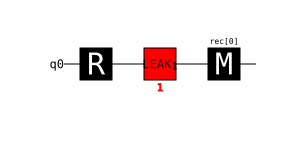

In [ ]:
# A circuit with guaranteed leakage. When a qubit leaks it is sent the the fully depolarised state. One way to simulate this (and how deltakit does it) is applying an X error with 50% followed by a Z error with 50%. This results in 1/4 chance for each of I, X, Y, Z. Over many samples, this is equivalent to the state being in the maximally depolarised state.

circuit = stim.Circuit("""
R 0
LEAKAGE(1) 0 
M 0
""")

sampler_object = circuit.compile_sampler()
# Run the circuit and show the measurement result. As we are measuring in the Z basis we will only see X or Y errors, which happen 50% of the time.
num_shots = 1000
print(f"X or Y errors:\n{sum(sampler_object.sample(shots = num_shots))[0]}/{num_shots}")
display(circuit.diagram("timeline-svg"))


First two elements are the measurement results of herald_leakage_event, second two are the measurements in the Z basis (flipped by X or Y errors):
[10  0  7  5]
Interestingly, leakage is not contagious. The other qubit gets fully depolarised but does not leak. Is depolarising leakage model in Natalie Brown's papers: 10.1103/physreva.100.032325, 10.1088/1367-2630/ab3372


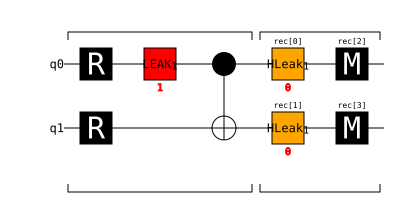

In [ ]:
# A measurement that can detect leakage 

circuit = stim.Circuit("""
R 0 1
LEAKAGE(1) 0 
CX 0 1
TICK
HERALD_LEAKAGE_EVENT() 0 1 # No argument in parenthesis means it detects leakage accurately. An argument (e.g. 0.3) means it fails with that probability
M 0 1
""")

sampler_object = circuit.compile_sampler()

# Run the circuit and show the measurement results.
num_shots = 10
print("First two elements are the measurement results of herald_leakage_event, second two are the measurements in the Z basis (flipped by X or Y errors):")
print(sum(sampler_object.sample(shots = num_shots)))
print("Interestingly, leakage is not contagious. The other qubit gets fully depolarised but does not leak. Is depolarising leakage model in Natalie Brown's papers: 10.1103/physreva.100.032325, 10.1088/1367-2630/ab3372")
display(circuit.diagram("timeline-svg"))


M0: 53/100
M1: 53/100


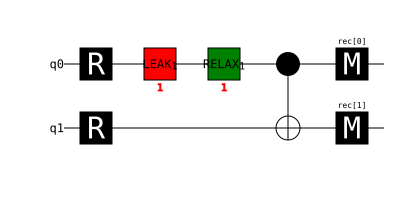

In [ ]:
# Equivalent circuits have either choice 1 OR choice 2 uncommented.

# The RELAX gate stops the qubit being leaked -- so it will no longer depolarize qubits it interacts with. Note though that it has been returned to the maximally depolarised state.
# Consequently, either including choice 1 (leakage and relax) OR choice 2 (depolarize(0.75), where p = 0.75 means 1/4 prob of each I, X, Y, Z which is p = 1 of converting to maximally depolarised state) in the circuit below gives the same outcomes: correlated measurements on the two qubits (both 1 50% of the time as this means an X or Y error occurred on the first qubit as was transferred through the CNOT).

# Only including leakage and no relax means maximally depolarize the first qubit which then maximally depolarizes the second qubit - so both have 50% chance of measuring 1 but will not be exactly correlated.

circuit = stim.Circuit("""
R 0 1

#### Choice 1 ###
LEAKAGE(1) 0
RELAX(1) 0
### End choice 1 ###

### Choice 2 ####
# DEPOLARIZE1(0.75) 0 
### End choice 2 ###

CX 0 1
M 0 1
""")

# Run the circuit and show the measurement results.
sampler_object = circuit.compile_sampler()
num_shots = 100
samples = sampler_object.sample(shots = num_shots)
print(f"M0: {sum(samples)[0]}/{num_shots}")
print(f"M1: {sum(samples)[1]}/{num_shots}")

circuit.diagram("timeline-svg")

rec[0]: 0/100
rec[1]: 48/100


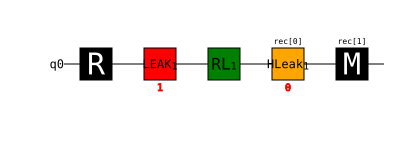

In [ ]:
circuit = stim.Circuit("""
R 0
LEAKAGE(1) 0
# R 0  ## Resetting actually puts it to |0⟩
RL 0   ## Leakage reset seems to be RELAX(p=1), i.e. not leaked anymore but is maximally depolarised state
HERALD_LEAKAGE_EVENT() 0
M 0 
""")

sampler_object = circuit.compile_sampler()
num_shots = 100
samples = sampler_object.sample(shots = num_shots)
print(f"rec[0]: {sum(samples)[0]}/{num_shots}")
print(f"rec[1]: {sum(samples)[1]}/{num_shots}")

circuit.diagram("timeline-svg")


### Generate Leaky Circuits

https://deltakit-docs.riverlane.com/en/stable/index.html

In [ ]:
from deltakit_circuit import Coord2D, Coord2DDelta, gates
from deltakit_explorer.codes import css_code_memory_circuit, RepetitionCode, RotatedPlanarCode, BivariateBicycleCode, ScheduleOrder, ScheduleType
from deltakit_circuit.gates import PauliBasis
from deltakit.explorer.qpu import SI1000Noise, SD6Noise, QPU, NativeGateSetAndTimes, ToyNoise, NoiseParameters

# My token:
import os
from deltakit_explorer import Client
os.environ["DELTAKIT_TOKEN"] = "-gacmW8zIhylEigvAtdul_hTBDNevfVF"
cloud = Client.get_instance()

In [ ]:
# Rotated surface code:
d = 2
code = RotatedPlanarCode(
    width = d,
    height = d,
    top_bumps_are_z = False
)
# code.draw_patch() # Nice visual
circuit = css_code_memory_circuit(
    css_code=code,
    num_rounds=2,
    logical_basis=PauliBasis.Z,  # Z-basis stabilisers protect from bit flips
)
stim_circuit = circuit.as_stim_circuit()
stim_circuit.to_file(f"../scrap.stim")
stim_circuit.diagram("timeline-svg")

In [ ]:
# Adding noise https://deltakit-docs.riverlane.com/en/stable/guide/adding_noise.html
# This can actually add noise to any stim circuit! If I save one of my own BB codes as scrap.stim from scrap.ipynb I can then import it here and noise is added.
# It also nicely and seemingly correctly updated the detector rec[]'s 

####### I just need to figure out how to change where it adds leakage and relax gates ... #########

## Actually it REPLACES noise too ... that's not what I want. I just wanted to add leakage and relax gates. Oh well, I know how to change my code to do so.

import stim
from deltakit.explorer.qpu import SI1000Noise

import os
from deltakit_explorer import Client
os.environ["DELTAKIT_TOKEN"] = "-gacmW8zIhylEigvAtdul_hTBDNevfVF"
cloud = Client.get_instance()

stim_circuit = stim.Circuit.from_file("../scrap.stim")
# display(stim_circuit.diagram("timeline-svg"))
si1000_leakage_noise = SI1000Noise(p=1e-3, pL=3e-3)
stim_text = cloud.add_noise(stim_circuit, si1000_leakage_noise)
# print(stim_text)

# If want to visualise the circuit as svg rather than just text in next cell (requires restarting kernel)
with open("scrap_circuit_noisy.txt", "w") as file:
    file.write(stim_text)

In [ ]:
# ## Visualising noise-replaced circuit as svg
# # requires RESTART KERNEL to use deltakit_stim

# import deltakit_stim as stim
# with open("scrap_circuit_noisy.txt", "r") as file:
#     stim_text = file.read()
# circuit = stim.Circuit(stim_text)
# svg = circuit.diagram('timeline-svg')
# display(svg)
# with open(f"../scrap.svg", "w", encoding="utf-8") as f: f.write(str(svg))

In [ ]:
# BB code, but only ones as per OG BB paper (A = x,y,y; B = y,x,x) and using their SE circuits:
# See: https://deltakit-docs.riverlane.com/en/stable/guide/circuit_generation.html#qldpc-codes

# The timeline-svg of their circuit seems very hard to follow but timeslice seems nice. They've also figured out how to position qubits such that it's the four nearest-neighbours then two long-range connections ... though maybe that's just under stricter paramaters of the OG BB paper.

### Simulation

Following [deltakit workbook](https://deltakit-docs.riverlane.com/en/stable/guide/simulation.html)

Can simulate using function [simulate_with_stim()](https://github.com/Deltakit/deltakit/blob/80087d51bbdbdafc149d1eb3882d53febbcf2216/deltakit-explorer/src/deltakit_explorer/simulation/_stim_simulation.py#L16).

Simulation can be done locally when doing Clifford circuits, but when simulating leaky circuits we need to provide a cloud client object, presumably meaning it is run on the riverlane devices ... 

In [1]:
### RESTART THE KERNEL! Need to import just stim not deltakit_stim otherwise it clashes with deltakit.explorer
import stim
from deltakit.explorer import types, Client, simulation
from deltakit.explorer.qpu import QPU, ToyNoise
from deltakit.explorer.codes import RepetitionCode, css_code_memory_circuit
from deltakit.circuit.gates import PauliBasis

import os
os.environ["DELTAKIT_TOKEN"] = "-gacmW8zIhylEigvAtdul_hTBDNevfVF"
cloud = Client.get_instance()

In [ ]:
# https://deltakit-docs.riverlane.com/en/stable/guide/simulation.html#leakage-simulation

from deltakit.explorer import Client, simulation
import numpy as np
import stim

cloud = Client.get_instance()

# in this circuit the qubit will leak then relax after measurement:
# note circuit is just plain text as it can't be simulated with stim.
leaky_circuit= """
    R 0 
    LEAKAGE(1) 0
    MZ 0
    HERALD_LEAKAGE_EVENT() 0
    RELAX(1) 0
    MZ 0
    HERALD_LEAKAGE_EVENT(0) 0
    """

measurements, leakage = simulation.simulate_with_stim(leaky_circuit, 10, client=cloud)  

print(f"measurements (shots are columns, subsequent measurements are rows):\n{measurements.as_numpy().T}")
print(f"leakage flags (shots are columns, subsequent measurementes are rows):\n{leakage.as_numpy().T}")

# So we note that the subsequent measurements agree, and about 50% of shots are flipped due to leakage.
# No leakage heralds after RELAX(1)

measurements (shots are columns, subsequent measurements are rows):
[[0 0 0 0 1 1 0 1 1 0]
 [0 0 0 0 1 1 0 1 1 0]]
leakage flags (shots are columns, subsequent measurementes are rows):
[[1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0]]


In [ ]:
# Two qubits:

leaky_circuit= """
    R 0 1
    LEAKAGE(1) 0
    MZ 0 1
    HERALD_LEAKAGE_EVENT() 0 1
    RELAX(1) 0
    MZ 0 1
    HERALD_LEAKAGE_EVENT(0) 0 1
    """

measurements, leakage = simulation.simulate_with_stim(leaky_circuit, 10, client=cloud)  ## simulate with stim actually uses deltakit_stim maybe? Because stim doesn't recognise 'LEAKAGE'.

print(f"measurements (shots are columns):\n{measurements.as_numpy().T}")
print(f"leakage flags (shots are columns):\n{leakage.as_numpy().T}")

measurements (shots are columns):
[[0 1 1 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0]]
leakage flags (shots are columns):
[[1 1 1 1 1 1 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [ ]:
## Simulating a leaky circuit?

from deltakit.explorer import types

noise = types.SI1000NoiseModel(p=1e-3, p_l=3e-3)
# note: this circuit is not compatible with Stim any more
leaky_circuit = cloud.add_noise(circuit.as_stim_circuit(), noise_model=noise)
measurements, leakage = simulation.simulate_with_stim(leaky_circuit, 100_000, client=cloud)

NameError: name 'circuit' is not defined

DEM: detector D0


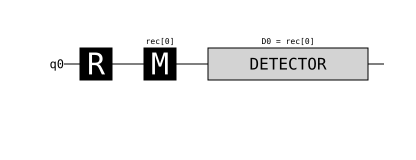

In [14]:
# With detectors
import sys
import deltakit_stim

# Save deltakit_stim as stim so any other calls to import stim (including from other packages) just use deltakit_stim:
injections = ['stim._detect_machine_architecture',
'stim._stim_polyfill',
'stim']
for namespace in injections:
    sys.modules[namespace] = sys.modules[f"deltakit_{namespace}"]

leaky_circuit= """
    R 0
    M 0
    DETECTOR rec[-1]
    """
circuit = deltakit_stim.Circuit(leaky_circuit)
print(f"DEM: {circuit.detector_error_model()}")
display(circuit.diagram("timeline-svg"))
# measurements, leakage = simulation.simulate_with_stim(leaky_circuit, 10, client=cloud)
# print(f"measurements (shots are columns):\n{measurements.as_numpy().T}")
# print(f"leakage flags (shots are columns):\n{leakage.as_numpy().T}")

### Decoding

[Decoding workbook section](https://deltakit-docs.riverlane.com/en/stable/guide/decoding.html)

Can't just plug circuits made with deltakit gates into sinter. Need to decode here by 
- Converting raw measurements into detector events and observable flips
- Giving the decoder the circuit and noise model
- Running the decoder on the detector measurements

In [ ]:
# repcode = RepetitionCode(distance=5)
# noiseless_deltakit_circuit = css_code_memory_circuit(repcode, num_rounds=5, logical_basis=PauliBasis.Z)

# qpu = QPU(qubits=noiseless_deltakit_circuit.qubits, noise_model=ToyNoise(p=0.03))
# deltakit_circuit = qpu.compile_and_add_noise_to_circuit(noiseless_deltakit_circuit)
# stim_circuit = deltakit_circuit.as_stim_circuit()

# measurements = stim_circuit.compile_sampler().sample(10_000)

# # convert them using deltakit
# deltakit_measurements = types.Measurements(measurements)
# detectors, observables = deltakit_measurements.to_detectors_and_observables(stim_circuit)

# print("Measurements:", measurements.shape)
# print("Detectors   :", detectors.as_numpy().shape)
# print("Observables :", observables.as_numpy().shape)

Measurements: (10000, 25)
Detectors   : (10000, 24)
Observables : (10000, 1)


In [1]:
import stim
from deltakit.explorer import types
from deltakit.explorer.qpu import QPU, ToyNoise
from deltakit.explorer.codes import RepetitionCode, css_code_memory_circuit
from deltakit.circuit.gates import PauliBasis

# repcode = RepetitionCode(distance=5)
# noiseless_deltakit_circuit = css_code_memory_circuit(repcode, num_rounds=5, logical_basis=PauliBasis.Z)

# qpu = QPU(qubits=noiseless_deltakit_circuit.qubits, noise_model=ToyNoise(p=0.03))
# deltakit_circuit = qpu.compile_and_add_noise_to_circuit(noiseless_deltakit_circuit)
# stim_circuit = deltakit_circuit.as_stim_circuit()

# measurements = stim_circuit.compile_sampler().sample(10_000)

# # convert them using deltakit
# deltakit_measurements = types.Measurements(measurements)
# detectors, observables = deltakit_measurements.to_detectors_and_observables(stim_circuit)

# print("Measurements:", measurements.shape)
# print("Detectors   :", detectors.as_numpy().shape)
# print("Observables :", observables.as_numpy().shape)

DEM error(0.05) D0
error(0.05) D1


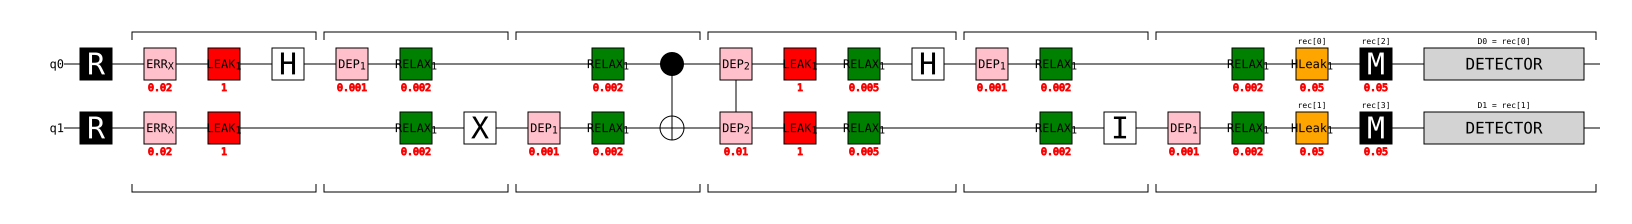

In [3]:
import deltakit_stim as stim

circuit = stim.Circuit("""R 0 1
TICK
X_ERROR(0.02) 0 1
LEAKAGE(1) 0 1
H 0
TICK
DEPOLARIZE1(0.001) 0
RELAX(0.002) 0 1
X 1
TICK
DEPOLARIZE1(0.001) 1
RELAX(0.002) 1 0
CX 0 1
TICK
DEPOLARIZE2(0.01) 0 1
LEAKAGE(1) 0 1
RELAX(0.005) 0 1
H 0
TICK
DEPOLARIZE1(0.001) 0
RELAX(0.002) 0 1
I 1
TICK
DEPOLARIZE1(0.001) 1
RELAX(0.002) 1 0
HERALD_LEAKAGE_EVENT(0.05) 0 1
M(0.05) 0 1
DETECTOR rec[-4]
DETECTOR rec[-3]
""")


print("DEM", circuit.detector_error_model())
circuit.diagram("timeline-svg")